In [ ]:
# -*- coding: utf-8 -*-
# Delaunay-driven underestimator with per-simplex lower-bound pruning
import pyomo.environ as pyo
from pyomo.environ import *
from pyomo.contrib.piecewise import PiecewiseLinearFunction
from pyomo.core.base import TransformationFactory
from pyomo.opt import SolverFactory
from pyomo.opt import SolverStatus, TerminationCondition

from dataclasses import dataclass
from typing import List, Dict, Tuple, Optional
import numpy as np
import itertools as it
import csv, time
from tqdm import tqdm
from scipy.spatial import Delaunay

# ============ 全局开关 ============
USE_DLOG = True          # PLF 线性化方式：DLOG / CC
PRUNE_EPS = 1e-2         # 剪枝容差 eps_prune
TIME_LIMIT = 1           # 每次子问题 TimeLimit（秒）
MIP_GAP   = 1e-1

# ----------------------- 线性化 & 校验 -----------------------
def apply_pw_transform(m):
    tx = ("contrib.piecewise.disaggregated_logarithmic"
          if USE_DLOG else
          "contrib.piecewise.convex_combination")
    TransformationFactory(tx).apply_to(m)

def assert_no_plf_left(m, where=""):
    leftovers = [c.name for c in m.component_objects(PiecewiseLinearFunction, active=True)]
    if leftovers:
        raise RuntimeError(f"[{where}] 还有未线性化的 PiecewiseLinearFunction: {leftovers}")

# ----------------------- 通用小工具 -----------------------
def del_components(model):
    for comp in ['obj', 'As', 'pw', 'pw_fun', 'pw_link']:
        if hasattr(model, comp):
            model.del_component(comp)

def _fmt_item(x, prec=6):
    if isinstance(x, (tuple, list)):
        return "(" + ", ".join(f"{float(v):.{prec}f}" for v in x) + ")"
    try:
        return f"{float(x):.{prec}f}"
    except Exception:
        return str(x)

def print_nodes_row(existing_nodes, new_node,
                    existing_values=None, new_value=None,
                    prec_node=2, prec_value=6, pad=2, label_new="(new node)",
                    highlight_min=True):
    headers = [f"node{i+1}" for i in range(len(existing_nodes))] + [f"node{len(existing_nodes)+1} {label_new}"]
    node_strs = [_fmt_item(n, prec_node) for n in existing_nodes] + [_fmt_item(new_node, prec_node)]
    have_vals = existing_values is not None or new_value is not None
    if existing_values is None: existing_values = [None] * len(existing_nodes)
    val_strs = []
    if have_vals:
        for v in existing_values:
            val_strs.append(_fmt_item(v, prec_value) if v is not None else "")
        val_strs.append(_fmt_item(new_value, prec_value) if new_value is not None else "")
    min_val = None
    if have_vals and highlight_min:
        try:
            nums = [float(v) for v in existing_values if v is not None]
            if new_value is not None: nums.append(float(new_value))
            if nums: min_val = min(nums)
        except Exception:
            pass
    cols = max(len(headers), len(node_strs))
    widths = []
    for j in range(cols):
        pieces = []
        if j < len(headers):   pieces.append(headers[j])
        if j < len(node_strs): pieces.append(node_strs[j])
        if have_vals and j < len(val_strs): pieces.append(val_strs[j])
        w = max(len(s) for s in pieces) + pad*2
        widths.append(w)
    def _center(s, w): return s.center(w)
    def _right(s, w):  return s.rjust(w)

    header_line = "".join(_center(h, widths[i]) for i, h in enumerate(headers))
    sep_line = "".join("-" * widths[i] for i in range(len(headers)))
    print(header_line)
    print(sep_line)
    node_line = "".join(_right(s, widths[i]) for i, s in enumerate(node_strs))
    print(node_line)
    if have_vals:
        val_line_parts = []
        for i, s in enumerate(val_strs):
            if s and min_val is not None and abs(float(s) - min_val) < 1e-12:
                colored = f"\033[31m{s}\033[0m"
                val_line_parts.append(_right(colored, widths[i] + 9))
            else:
                val_line_parts.append(_right(s, widths[i]))
        print("".join(val_line_parts))

def corners_from_bounds(first_stg_vars):
    bounds = []
    for y in first_stg_vars:
        lb, ub = y.lb, y.ub
        if lb is None or ub is None:
            raise ValueError(f"{y.name} 缺少上下界，无法生成角点")
        bounds.append((float(lb), float(ub)))
    return list(it.product(*[(lb, ub) for (lb, ub) in bounds]))

# ----------------------- n 维分片：为 sum-模型搭桥 -----------------------
def add_nd_piecewise(model, first_stg_vars, points, values,
                     name="pw", relation="==", round_ndigits=12):
    if len(points) == 0:
        raise ValueError("points 不能为空")
    N = len(first_stg_vars)
    for pt in points:
        if len(pt) != N:
            raise ValueError(f"points 中出现与 x_vars 维度不一致的点: {pt}")
    del_components(model)

    def keyize(coords):
        return tuple(round(float(c), round_ndigits) for c in coords)
    norm_points = [keyize(pt) for pt in points]

    if isinstance(values, dict):
        table = {keyize(k): float(v) for k, v in values.items()}
        miss = [pt for pt in norm_points if pt not in table]
        if miss:
            raise KeyError(f"values 缺少这些点的取值: {miss[:5]}{' ...' if len(miss)>5 else ''}")
    else:
        if len(values) != len(points):
            raise ValueError("values 长度应与 points 数量一致（或传 dict）")
        table = {pt: float(v) for pt, v in zip(norm_points, values)}

    def _f_from_table(*coords):
        return table[keyize(coords)]

    pw = PiecewiseLinearFunction(points=norm_points, function=_f_from_table, name=f"{name}_fun")
    model.add_component(pw.name, pw)
    pw_expr = pw(*first_stg_vars)

    As = pyo.Var(name=f"{name}_As")
    model.add_component(As.name, As)
    if relation == "==":
        link = pyo.Constraint(expr=As == pw_expr)
    elif relation == ">=":
        link = pyo.Constraint(expr=As >= pw_expr)
    elif relation == "<=":
        link = pyo.Constraint(expr=As <= pw_expr)
    else:
        raise ValueError("relation 只能是 '==', '>=', '<='")
    model.add_component(f"{name}_link", link)
    return As, pw

# ----------------------- 模型构建（PID 场景） -----------------------
def load_scenarios_from_csv(csv_path: str, T: Optional[int] = None,
                            sp0: float = 0.0, sp1: float = 0.5,
                            ku_col: str = "tau_us", tau_col: str = "tau_xs",
                            disturb_prefix: str = "disturbance_",
                            setpoint_change_col: str = "setpoint_change") -> Tuple[List[Dict], int]:
    scens: List[Dict] = []
    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        fieldnames = reader.fieldnames or []
        if T is None:
            max_idx = -1
            for name in fieldnames:
                if name.startswith(disturb_prefix):
                    try:
                        k = int(name[len(disturb_prefix):]); max_idx = max(max_idx, k)
                    except:
                        pass
            if max_idx < 0:
                raise ValueError(f"未找到 '{disturb_prefix}k' 格式的扰动列")
            T = max_idx

    with open(csv_path, "r", newline="", encoding="utf-8") as f:
        reader = csv.DictReader(f)
        for row in reader:
            if ku_col not in row or tau_col not in row:
                raise KeyError(f"CSV 缺少必要列: '{ku_col}' 或 '{tau_col}'")
            Ku  = float(row[ku_col]); tau = float(row[tau_col])

            d = []
            for t in range(T+1):
                col = f"{disturb_prefix}{t}"
                if col not in row: raise KeyError(f"CSV 缺少扰动列: {col}")
                d.append(float(row[col]))

            sp = [sp1]*(T+1)
            if setpoint_change_col in row and row[setpoint_change_col] != "":
                try:
                    t_star = int(float(row[setpoint_change_col]))
                    for t in range(T+1):
                        sp[t] = sp0 if t < t_star else sp1
                except:
                    pass

            scens.append({"Ku": Ku, "tau": tau, "d": d, "sp": sp})
    return scens, T

def build_pid_model(T=10, h=0.2, scen=None, weights=(1.0, 0.01), bounds=None):
    assert scen is not None, "请提供一个场景字典"
    Ku, tau, d, sp = scen["Ku"], scen["tau"], scen["d"], scen["sp"]
    assert len(d) == T+1 and len(sp) == T+1

    if bounds is None: bounds = {}
    bx = bounds.get("x",  (-20, 20))
    bu = bounds.get("u",  (None, None))
    bKp= bounds.get("Kp", (0, 100))
    bKi= bounds.get("Ki", (0, 100))
    bKd= bounds.get("Kd", (0, 100))
    be = bounds.get("e",  (-100, 100))
    bI = bounds.get("I",  (-200, 200))

    m = pyo.ConcreteModel()
    m.T  = pyo.RangeSet(0, T)
    m.Tm = pyo.RangeSet(1, T)

    m.Kp = pyo.Var(bounds=bKp)
    m.Ki = pyo.Var(bounds=bKi)
    m.Kd = pyo.Var(bounds=bKd)

    m.x = pyo.Var(m.T, bounds=bx)
    m.u = pyo.Var(m.T, bounds=bu)
    m.e = pyo.Var(m.T, bounds=be)
    m.I = pyo.Var(m.T, bounds=bI)

    def _err_rule(m, t): return m.e[t] == sp[t] - m.x[t]
    m.err_def = pyo.Constraint(m.T, rule=_err_rule)

    def _I_dyn(m, t): return m.I[t] == m.I[t-1] + h*m.e[t]
    m.I_dyn = pyo.Constraint(m.Tm, rule=_I_dyn)

    def _x_dyn(m, t):
        return m.x[t] == m.x[t-1] + (h/tau)*(-m.x[t] + Ku*m.u[t] + d[t])
    m.x_dyn = pyo.Constraint(m.Tm, rule=_x_dyn)

    def _pid_rule(m, t):
        if t == 0:
            return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t]
        return m.u[t] == m.Kp*m.e[t] + m.Ki*m.I[t] + m.Kd*(m.e[t]-m.e[t-1])/h
    m.pid = pyo.Constraint(m.T, rule=_pid_rule)

    m.x0 = pyo.Constraint(expr=m.x[0] == 0)
    m.I0 = pyo.Constraint(expr=m.I[0] == 0)

    w_e, w_u = weights
    m.cost = pyo.Expression(expr=sum(h*(w_e*m.e[t]**2 + w_u*m.u[t]**2) for t in m.T))
    m.obj_expr = pyo.Expression(expr=m.cost)
    return m, [m.Kp, m.Ki, m.Kd]

def build_models_from_csv(csv_path: str, h: float = 0.2,
                          weights=(1.0, 0.01), bounds=None,
                          sp0: float = 0.0, sp1: float = 0.5,
                          ku_col: str = "tau_us", tau_col: str = "tau_xs",
                          disturb_prefix: str = "disturbance_",
                          setpoint_change_col: str = "setpoint_change",
                          max_scenarios=None, skip=0):
    scens, T = load_scenarios_from_csv(
        csv_path=csv_path, T=None, sp0=sp0, sp1=sp1,
        ku_col=ku_col, tau_col=tau_col,
        disturb_prefix=disturb_prefix, setpoint_change_col=setpoint_change_col,
    )
    if skip or max_scenarios:
        scens = scens[skip: (skip + max_scenarios) if max_scenarios else None]

    model_list, first_stg_vars_list = [], []
    for scen in scens:
        m, yvars = build_pid_model(T=T, h=h, scen=scen, weights=weights, bounds=bounds)
        model_list.append(m)
        first_stg_vars_list.append(yvars)

    m_tmpl_list = [model_list[0], first_stg_vars_list[0]]
    return model_list, first_stg_vars_list, m_tmpl_list, T

# ----------------------- 场景评估 Q(y) -----------------------
def evaluate_Q_at(model, first_stg_vars, first_stg_vals, solver):
    del_components(model)
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(float(v))
    model.obj = pyo.Objective(expr=model.obj_expr, sense=pyo.minimize)
    try:
        results = solver.solve(model, tee=False)
        status_ok = (results.solver.status == SolverStatus.ok)
        term_ok   = (results.solver.termination_condition == TerminationCondition.optimal)
        if not (status_ok and term_ok):
            raise RuntimeError(
                f"Evaluate at y={first_stg_vals} not optimal: "
                f"status={results.solver.status}, term={results.solver.termination_condition}"
            )
        return float(pyo.value(model.obj_expr))
    finally:
        if hasattr(model, 'obj'):
            model.del_component('obj')
        for u in first_stg_vars:
            if u.fixed: u.unfix()

# ----------------------- 单形块管理 + 逐单形求 ms -----------------------
def drop_simplex_block_and_obj(m):
    for nm in ['simp', 'obj']:
        if hasattr(m, nm):
            m.del_component(nm)

def per_simplex_ms_nd(model, first_stage_vars, tri: Delaunay,
                      nodes: List[Tuple[float, ...]],
                      values: List[float],
                      simplex_indices: Optional[List[int]],
                      solver, tee=False):
    """
    在给定 tri（Delaunay）及其 simplex 子集上，逐单形求：
        ms = min_{x in simplex} (obj_expr - As)
    其中 As 在单形内由顶点值 (values) 线性插值；同时返回 verts_As_min = min顶点 Q 值。
    返回 dict: simplex_index -> { 'ms', 'x_star', 'verts_As_min', ... }
    """
    pts  = np.asarray(nodes, dtype=float)
    vals = np.asarray(values, dtype=float)
    assert pts.ndim == 2 and vals.ndim == 1 and len(vals) == len(pts), "nodes/values 维度不匹配"

    if simplex_indices is None:
        simplex_indices = list(range(len(tri.simplices)))

    n = pts.shape[1]
    if hasattr(model, 'As'):
        model.del_component('As')
    model.As = pyo.Var()

    results: Dict[int, Dict] = {}
    x_last = None

    for k in simplex_indices:
        simp = tri.simplices[k]
        V = pts[simp, :]     # (n+1, n)
        F = vals[simp]       # (n+1,)

        if x_last is not None:
            for d, y in enumerate(first_stage_vars):
                try: y.value = float(x_last[d])
                except: pass

        model.simp = pyo.Block()
        model.simp.lam = pyo.Var(range(n+1), domain=pyo.NonNegativeReals)
        model.simp.lam_sum = pyo.Constraint(expr=sum(model.simp.lam[j] for j in range(n+1)) == 1.0)

        model.simp.y_link = pyo.ConstraintList()
        for d, y in enumerate(first_stage_vars):
            model.simp.y_link.add(y == sum(model.simp.lam[j]*float(V[j, d]) for j in range(n+1)))

        model.simp.As_con = pyo.Constraint(expr=model.As == sum(model.simp.lam[j]*float(F[j]) for j in range(n+1)))

        model.obj = pyo.Objective(expr=model.obj_expr - model.As, sense=pyo.minimize)

        res = solver.solve(model, tee=tee)
        x_star = [float(pyo.value(y)) for y in first_stage_vars]
        ms_val = float(pyo.value(model.obj))

        results[int(k)] = {
            "simplex_index": int(k),
            "verts_index": simp.tolist(),
            "x_star": x_star,
            "ms": ms_val,
            "verts_As_min": float(np.min(F)),
            "status": str(res.solver.status),
            "term": str(res.solver.termination_condition),
        }

        x_last = x_star
        drop_simplex_block_and_obj(model)

    return results

# ============================== 主程序 ==============================
if __name__ == "__main__":
    # ---------- 可调参数 ----------
    csv_path = "data.csv"
    max_scenarios = 2
    target_nodes  = 20
    bounds = {
        "x":  (None, None),
        "u":  (None, None),
        "e":  (None, None),
        "I":  (-10, 10),
        "Kp": (0, 1),
        "Ki": (0, 1),
        "Kd": (0, 1),
    }
    weights = (1.0, 0.01)

    # ---------- 构建场景模型 ----------
    model_list, first_stg_vars_list, m_tmpl_list, T = build_models_from_csv(
        csv_path, h=0.2, weights=weights, bounds=bounds,
        sp0=0.0, sp1=0.5, ku_col="tau_us", tau_col="tau_xs",
        disturb_prefix="disturbance_", setpoint_change_col="setpoint_change",
        max_scenarios=max_scenarios, skip=0
    )
    N = len(model_list)

    # ---------- Gurobi 求解器 ----------
    solver = SolverFactory('gurobi')
    solver.options.update({
        'MIPGap':       MIP_GAP,
        'NumericFocus': 1,
        'Presolve':     2,
        'NonConvex':    2,
        'TimeLimit':    TIME_LIMIT,
    })

    # ---------- 初始化：角点 + 在角点处评估 Q_i(y) ----------
    as_nodes_list: List[List[float]] = [[] for _ in range(N)]  # 每场景：节点上的 Q_i 值
    ms_list: List[float] = [None] * N                          # 每轮每场景的 min_k ms_{i,Δk}
    new_nodes_list: List[Tuple[float,...]] = [None] * N

    LB_history, UB_history = [], []
    UB_node_history, add_node_history, ms_history, sum_ms_list, k_list = [], [], [], [], []

    first_stg_nodes = corners_from_bounds(first_stg_vars_list[0])
    for i in range(N):
        as_nodes_list[i].extend(
            evaluate_Q_at(model_list[i], first_stg_vars_list[i], node, solver)
            for node in first_stg_nodes
        )
    print('corner nodes are ', first_stg_nodes)
    print('as_nodes_list are ', as_nodes_list)

    # 初始 UB 节点（节点上 ∑Q_i 最小处）
    arr = np.array(as_nodes_list, dtype=float, ndmin=2)
    assum_nodes = arr.sum(axis=0)
    min_index = int(np.argmin(assum_nodes))
    if len(first_stg_nodes) == len(assum_nodes):
        UB_node_history.append(first_stg_nodes[min_index])

    print('Start from ', len(first_stg_nodes), ' corner nodes; target =', target_nodes)

    # ---------- 主循环 ----------
    for k in tqdm(range(len(first_stg_nodes)+1, target_nodes+1), desc="Adding nodes"):
        print('\n'+'#'*54)
        print(f'Start adding node {k}')
        k_list.append(k)

        # ========== 本轮 Delaunay 与活跃单形集 ==========
        pts = np.asarray(first_stg_nodes, dtype=float)
        tri = Delaunay(pts)  # 每轮重建，不跨轮继承
        active_simplices = list(range(len(tri.simplices)))

        # ========== 逐场景：在活跃单形上求 ms_{i,Δ} 和 verts_As_min ==========
        per_scen_results: List[Dict[int, Dict]] = []
        for i in range(N):
            print(f'[scenario {i}] per-simplex solve on {len(active_simplices)} simplices')
            res_i = per_simplex_ms_nd(
                model=model_list[i],
                first_stage_vars=first_stg_vars_list[i],
                tri=tri,
                nodes=first_stg_nodes,
                values=as_nodes_list[i],
                simplex_indices=active_simplices,
                solver=solver,
                tee=False
            )
            per_scen_results.append(res_i)

        # ========== 聚合：构造每个单形的全局下界 LB_Δ ==========
        LB_piece: Dict[int, float] = {}
        for sidx in active_simplices:
            tot = 0.0
            for i in range(N):
                ri = per_scen_results[i][sidx]
                tot += ri["ms"] + ri["verts_As_min"]
            LB_piece[sidx] = tot

        # ========== 计算 UB_true 与 UB_pw，并取 UB = min(...) ==========
        # UB_true: 在当前节点中，取 ∑Q_i 最小的节点真实评估
        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        assum_nodes = arr.sum(axis=0)
        ubnode_index = int(np.argmin(assum_nodes))
        UB_node = first_stg_nodes[ubnode_index]

        UB_true = 0.0
        for i in range(N):
            UB_true += evaluate_Q_at(model_list[i], first_stg_vars_list[i], UB_node, solver)

        # UB_pw: min_x Σ_i A_i(x)  —— 用 sum-model（一次 PLF）求
        model_sum, model_sum_first_stg_vars = model_list[0].clone(), []
        for v in first_stg_vars_list[0]:
            model_sum_first_stg_vars.append(model_sum.find_component(v.name))
        del_components(model_sum)

        # Σ_i A_i 的顶点值 = Σ_i Q_i(node)
        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        assum_nodes = arr.sum(axis=0)

        As_sum, pw_sum = add_nd_piecewise(
            model_sum, model_sum_first_stg_vars, first_stg_nodes, assum_nodes,
            name="pw_sum", relation="=="
        )
        model_sum.obj = Objective(expr=As_sum, sense=minimize)
        apply_pw_transform(model_sum)
        assert_no_plf_left(model_sum, where="sum")

        res_sum = solver.solve(model_sum, tee=False)
        UB_pw = float(pyo.value(As_sum))

        UB = min(UB_true, UB_pw)

        # ========== 剪枝：LB_piece >= UB - PRUNE_EPS 的单形移除 ==========
        pruned = [s for s, lb in LB_piece.items() if lb >= UB - PRUNE_EPS]
        if pruned:
            print(f'[prune] {len(pruned)}/{len(active_simplices)} simplices pruned by LB>=UB-eps')
        active_set = [s for s in active_simplices if s not in pruned]

        # ========== 每场景的 ms_list[i] = 活跃单形里的 min ms ==========
        for i in range(N):
            cand = [per_scen_results[i][s]["ms"] for s in active_set] if active_set else []
            ms_list[i] = min(cand) if cand else float('inf')

        # ========== 本轮的 LB、UB（算法式）：LB = min_nodes Σ_i A_i(node) + Σ_i min_Δ ms_{i,Δ} ==========
        arr = np.array(as_nodes_list, dtype=float, ndmin=2)
        As_min_nodes = float(np.min(arr.sum(axis=0)))
        sum_ms = float(sum(ms_list[i] for i in range(N)))
        LB_k = As_min_nodes + sum_ms
        LB_history.append(LB_k)

        # 存历史 UB（这里记录 UB=min(UB_true, UB_pw)）
        UB_history.append(UB)

        print(f"[iteration {k}] LB = {LB_history[-1]:.6f}")
        print(f"[iteration {k}] UB_true = {UB_true:.6f} , UB_pw = {UB_pw:.6f} , UB = {UB:.6f}")
        print(f"--> Current gap = {UB_history[-1] - LB_history[-1]:.6f}")

        # ========== 选新节点：在活跃单形中取全局最小 ms 的 x* ==========
        best_global = None  # (ms, scenario_id, simplex_id, x_star)
        for i in range(N):
            for s in active_set:
                ms_val = per_scen_results[i][s]["ms"]
                x_star = per_scen_results[i][s]["x_star"]
                item = (ms_val, i, s, x_star)
                if (best_global is None) or (ms_val < best_global[0]):
                    best_global = item

        if best_global is None:
            print("No active simplex left; stopping early.")
            break

        _, pick_i, pick_s, x_star = best_global
        new_node = tuple(float(v) for v in x_star)

        # ========== 加新节点，更新各场景节点值 ==========
        new_node_value_sum = 0.0
        for i in range(N):
            qval = evaluate_Q_at(model_list[i], first_stg_vars_list[i], new_node, solver)
            as_nodes_list[i].append(qval)
            new_node_value_sum += qval
        first_stg_nodes.append(new_node)

        # 记录
        ms_history.append(ms_list.copy())
        add_node_history.append(new_node)
        UB_node_history.append(UB_node)

        print_nodes_row(
            existing_nodes=first_stg_nodes[:-1],
            new_node=new_node,
            existing_values=np.array(as_nodes_list, dtype=float, ndmin=2).sum(axis=0)[:-1],
            new_value=new_node_value_sum,
            prec_node=3, prec_value=6
        )
        print(f'Chosen new node (from scenario {pick_i}, simplex {pick_s}) = {new_node}')
        print('*****************************************')

    # ---------- 总结 ----------
    print("\n================= SUMMARY =================")
    print("num scenarios:", N)
    print("num nodes:", len(first_stg_nodes))
    print("final LB:", LB_history[-1] if LB_history else None)
    print("final UB:", UB_history[-1] if UB_history else None)
    print("UB gap (abs):", (UB_history[-1] - LB_history[-1]) if LB_history and UB_history else None)
    print("Last new node:", add_node_history[-1] if add_node_history else None)
    print("ms_history length (iterations):", len(ms_history))


corner nodes are  [(0.0, 0.0, 0.0), (0.0, 0.0, 1.0), (0.0, 1.0, 0.0), (0.0, 1.0, 1.0), (1.0, 0.0, 0.0), (1.0, 0.0, 1.0), (1.0, 1.0, 0.0), (1.0, 1.0, 1.0)]
as_nodes_list are  [[3.9007114612311193, 2.4205920396552045, 1.109851487426659, 0.5593037176349518, 0.9777785873250637, 0.792440233468763, 0.5164290177529021, 0.3616264624871053], [3.054419096960109, 1.772467228928573, 1.275236781560554, 0.4623751762304345, 0.6486041311839825, 0.5044991827148441, 0.4460209546225892, 0.27141388844990705]]
Start from  8  corner nodes; target = 20


Adding nodes:   0%|          | 0/12 [00:00<?, ?it/s]


######################################################
Start adding node 9
[scenario 0] per-simplex solve on 6 simplices
containing a solution
containing a solution
containing a solution
[scenario 1] per-simplex solve on 6 simplices
containing a solution
containing a solution
containing a solution
containing a solution
[iteration 9] LB = -2.371711
[iteration 9] UB_true = 0.633040 , UB_pw = 0.633040 , UB = 0.633040
--> Current gap = 3.004751


Adding nodes:   8%|▊         | 1/12 [00:11<02:08, 11.72s/it]

          node1                    node2                    node3                    node4                    node5                    node6                    node7                    node8               node9 (new node)    
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.000, 0.000, 0.000)    (0.000, 0.000, 1.000)    (0.000, 1.000, 0.000)    (0.000, 1.000, 1.000)    (1.000, 0.000, 0.000)    (1.000, 0.000, 1.000)    (1.000, 1.000, 0.000)    (1.000, 1.000, 1.000)    (0.000, 0.295, 0.288)
                 6.955131                 4.193059                 2.385088                 1.021679                 1.626383                 1.296939                 0.962450                 0.633040                 2.216740
Chosen new node (from scenario 0, simplex 0) = (1.120456602721116e-09, 0.29487948637557365, 0.28

...

          node1                    node2                    node3                    node4                    node5                    node6                    node7                    node8                    node9                    node10                   node11                   node12                   node13                   node14             node15 (new node)    
---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.000, 0.000, 0.000)    (0.000, 0.000, 1.000)    (0.000, 1.000, 0.000)    (0.000, 1.000, 1.000)    (1.000, 0.000, 0.000)    (1.000, 0.000, 1.000)    (1.000, 1.000, 0.000)    (1.000, 1.000, 1.000)    (0.000, 0.295, 0.288)    (0.000, 0.297, 0.07

Adding nodes:  67%|██████▋   | 8/12 [03:00<01:46, 26.67s/it]

          node1                    node2                    node3                    node4                    node5                    node6                    node7                    node8                    node9                    node10                   node11                   node12                   node13                   node14                   node15             node16 (new node)    
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.000, 0.000, 0.000)    (0.000, 0.000, 1.000)    (0.000, 1.000, 0.000)    (0.000, 1.000, 1.000)    (1.000, 0.000, 0.000)    (1.000, 0.000, 1.000)    (1.000, 1.000, 0.000)    (1.000, 1.000, 1.00

Adding nodes:  75%|███████▌  | 9/12 [03:39<01:31, 30.57s/it]

          node1                    node2                    node3                    node4                    node5                    node6                    node7                    node8                    node9                    node10                   node11                   node12                   node13                   node14                   node15                   node16             node17 (new node)    
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
    (0.000, 0.000, 0.000)    (0.000, 0.000, 1.000)    (0.000, 1.000, 0.000)    (0.000, 1.000, 1.000)    (1.000, 0.000, 0.000)    (1.000, 0.000, 1.00

In [4]:
print("\nLB_history =", LB_history)
print("UB_history =", UB_history)



LB_history = [-5.062795268613963, -4.723666580858826, -4.641146562977817, -4.641146562977555, -4.58205659656463, -4.582056599872001, -4.553750833352153, -4.553750833353215, -4.553750833353362, -3.755879145118797, -3.7558791468061656, -3.7558791468043022]
UB_history = [0.3033637230558613, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123, 0.30336372305586123]


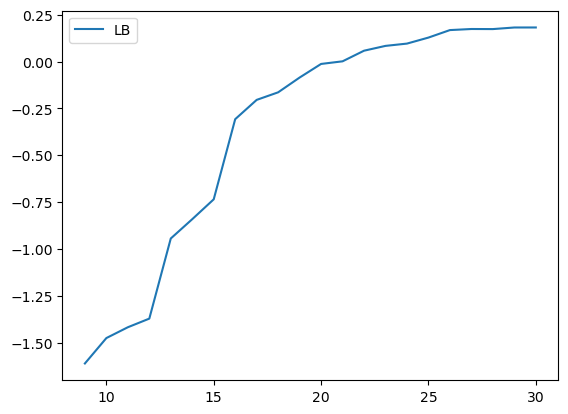

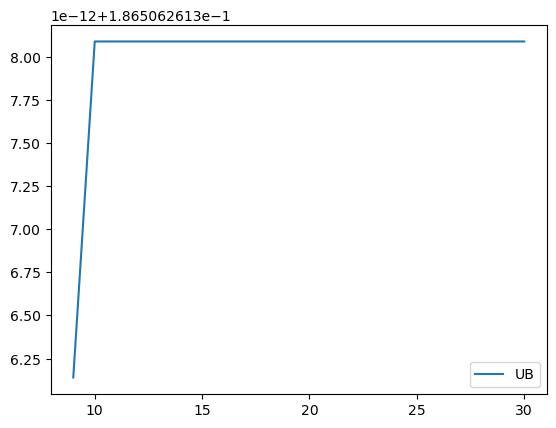

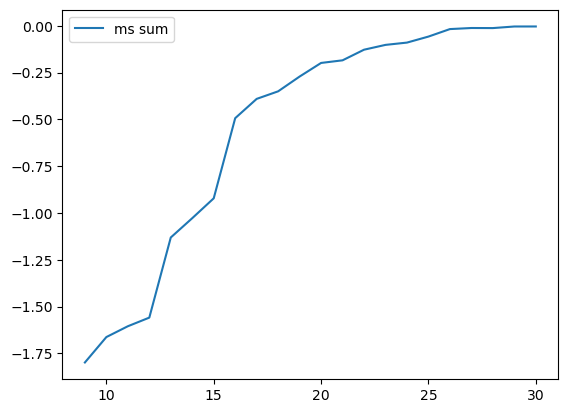

-1.7982114171770147
-1.6624712404405084
-1.6047491615046585
-1.5586715801492896
-1.130754168028989
-1.0276208568784175
-0.9215638198204993
-0.4936286032617928
-0.390604956782925
-0.35024026285166016
-0.27132894508141886
-0.19866794366466808
-0.18467509682280042
-0.12796843825022527
-0.10223993584492427
-0.08998868363855445
-0.05788153098461511
-0.0178501274543862
-0.012103119631627706
-0.012513158794490574
-0.004025266969280189
-0.003939511521008108


In [10]:
LB_history = [x / max_scenarios for x in LB_history]
UB_history = [x / max_scenarios for x in UB_history]
sum_ms_list = [x / max_scenarios for x in sum_ms_list]

plt.figure()
plt.plot(k_list, LB_history, label="LB")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_list, UB_history, label="UB")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_list, sum_ms_list, label="ms sum")
plt.legend()
plt.show()

'''
for i in range(len(ms_history[0])):
    plt.figure()
    plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
    plt.legend()
    plt.show()
'''
for item in sum_ms_list:
    print(item)


In [ ]:
import pandas as pd, json

def read_data(name, plot=False, result_from_SNOG=None):
    '''
    name is data file name end in .csv
    plot control if show figures
    result_from_SNOG = [UB_SNOG, LB_SNOG] control if show SNOG result
    '''
    df = pd.read_csv(name)
    k_list = df["k"].tolist()
    LB_history = df["LB"].tolist()
    UB_history = df["UB"].tolist()
    sum_ms_list = df["sum_ms"].tolist()
    df["ms"] = df["ms"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["added_nodes"] = df["added_nodes"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["UB_node"] = df["UB_node"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["new_nodes"] = df["new_nodes"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    df["as_nodes"] = df["as_nodes"].apply(lambda x: json.loads(x) if pd.notnull(x) else None)
    ms_history = df["ms"].tolist()
    add_node_history = df["added_nodes"].tolist()
    UB_node_history = df["UB_node"].tolist()
    new_nodes_list = df["new_nodes"].tolist()
    as_nodes_list = df["as_nodes"].tolist()

    if plot:
        plt.figure()
        plt.plot(k_list, LB_history, label="LB")
        plt.title("LB vs node_num")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(k_list, LB_history, label="LB")
        plt.plot(k_list, UB_history, label="UB")
        if result_from_SNOG is not None:
            plt.axhline(y=result_from_SNOG[0], color="b", linestyle="--", label="UB_SNOG")
            plt.axhline(y=result_from_SNOG[1], color="r", linestyle="--", label="LB_SNOG")
        plt.title("comparison")
        plt.legend()
        plt.show()

        plt.figure()
        plt.plot(k_list, sum_ms_list, label="LB sum")
        plt.legend()
        plt.show()

        sum_ms_list = []
        for i in range(len(ms_history[0])):
            plt.figure()
            plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
            plt.legend()
            plt.show()

    return k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list


k_list, LB_history, UB_history, sum_ms_list, ms_history, add_node_history, UB_node_history, new_nodes_list, as_nodes_list = read_data("mydata1.csv")

[-21.47775638406714, -14.435869132000509, -14.190668068272595, -11.08905724276278, -8.201214367657592, -4.74831646359296, -4.585168146260724, -4.546278144036258, -3.589477780229661, -4.781854306812786, -2.4278749624133127, 0.9323731252956726, 2.5625829785801137, 3.2992610988383757, 9.078338650246453, 11.73049268606026, 13.5441475532832, 16.22907228315789, 18.71492811795681, 18.48040388314001, 17.06065377068723, 18.652884789780483]
22
22


In [28]:
ms_sum_list = []
for msi in ms_history:
    ms_sum_list.append(np.sum(msi))
ms_sum_list

[np.float64(-8.072092788529588),
 np.float64(-7.359502670636397),
 np.float64(-6.379018070496092),
 np.float64(-5.44995938445652),
 np.float64(-5.348067240461682),
 np.float64(-5.021291916672919),
 np.float64(-4.597611242606977),
 np.float64(-4.5341286539337),
 np.float64(-4.430079369931795),
 np.float64(-4.047274348177888),
 np.float64(-3.8028255864502456),
 np.float64(-3.6758099219328884),
 np.float64(-2.951286148923419),
 np.float64(-2.312917273567643),
 np.float64(-1.9447403951090623),
 np.float64(-1.525327426094635),
 np.float64(-1.2860360963417117),
 np.float64(-0.7960397353834741),
 np.float64(-0.5592009051547151),
 np.float64(-0.6048698478735713),
 np.float64(-0.45401453533067415),
 np.float64(-0.34483977880129835)]

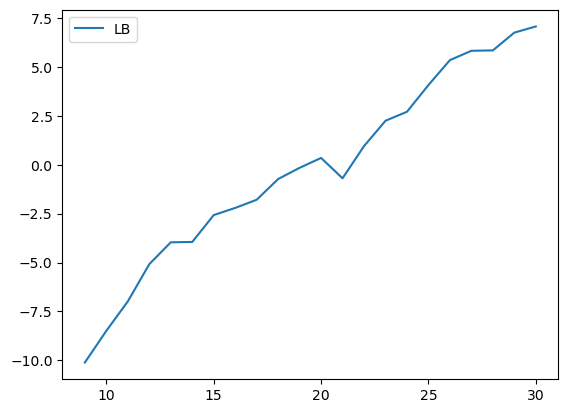

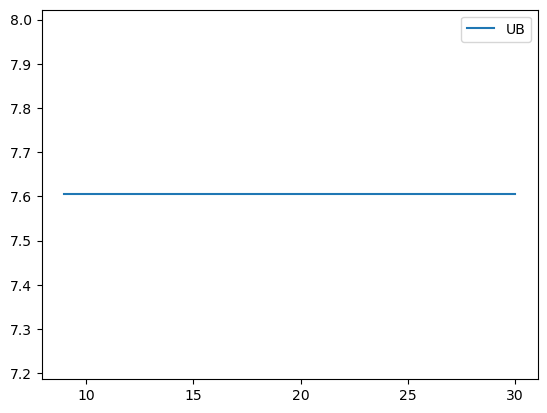

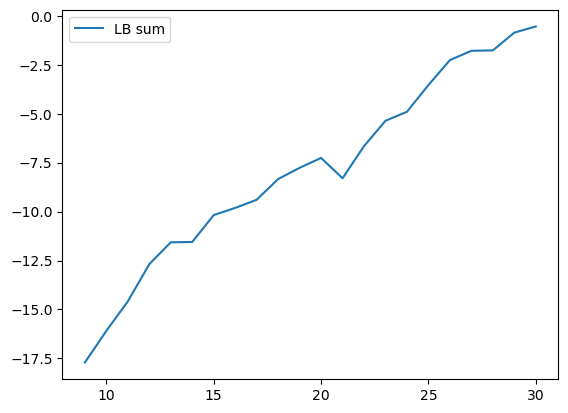

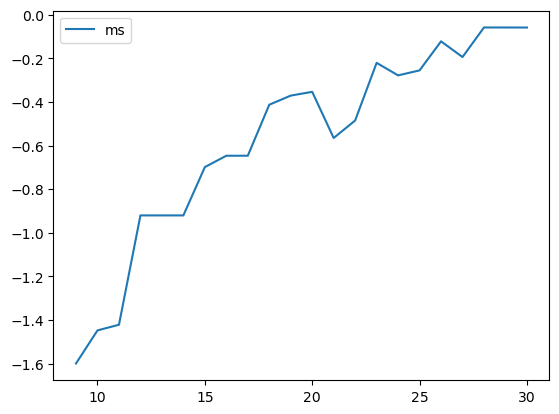

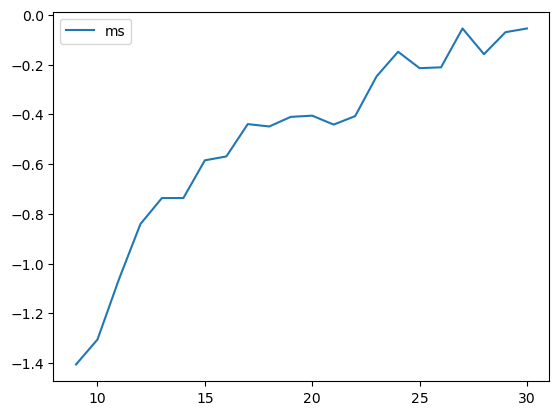

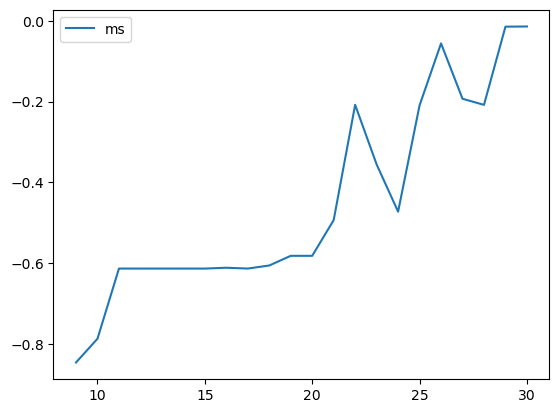

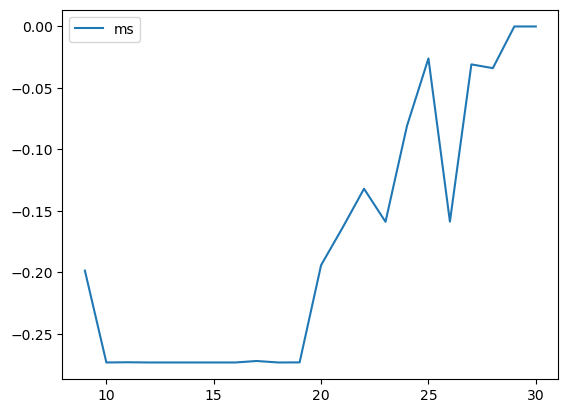

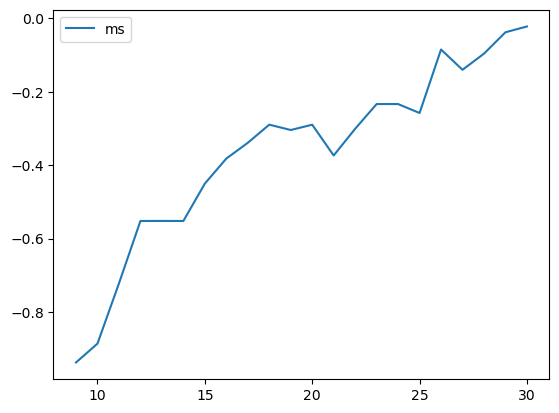

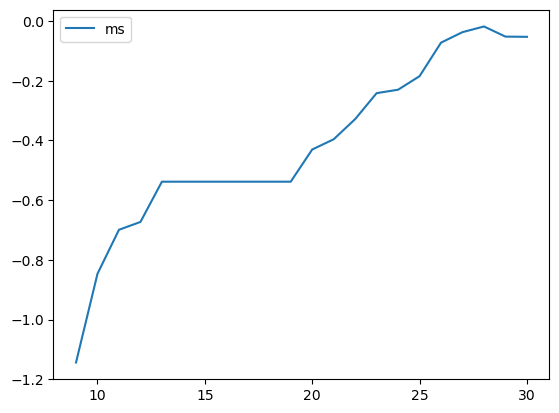

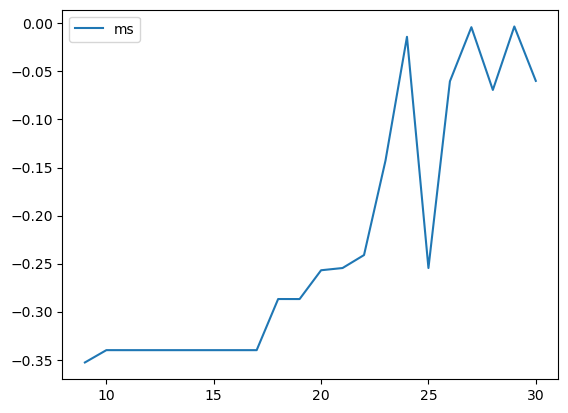

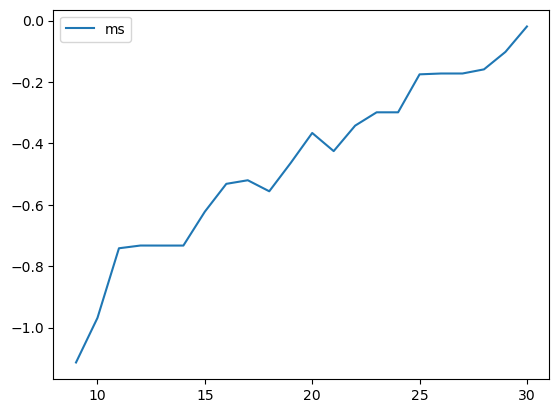

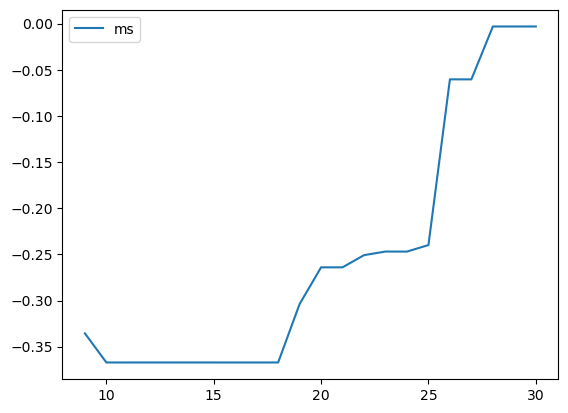

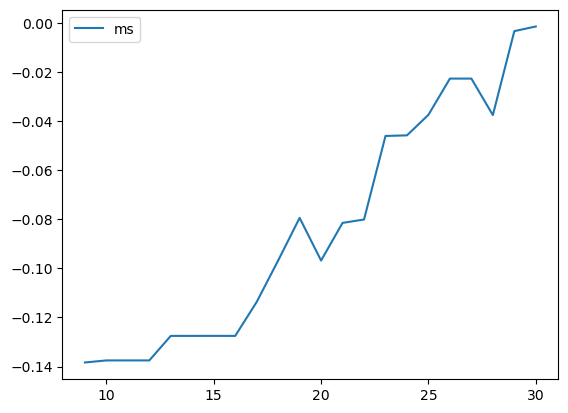

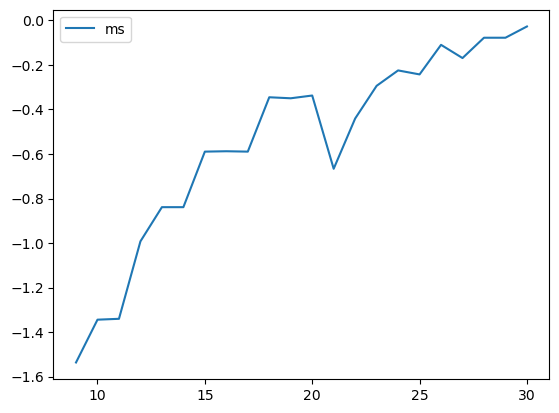

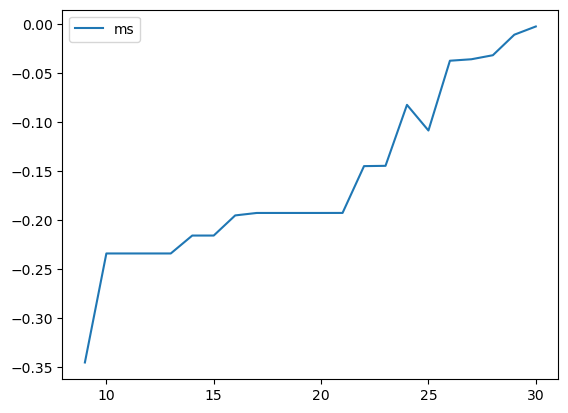

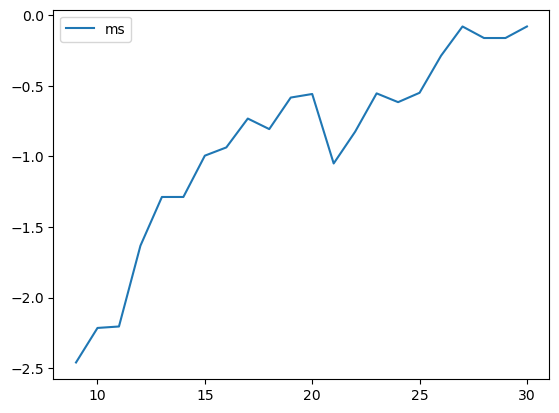

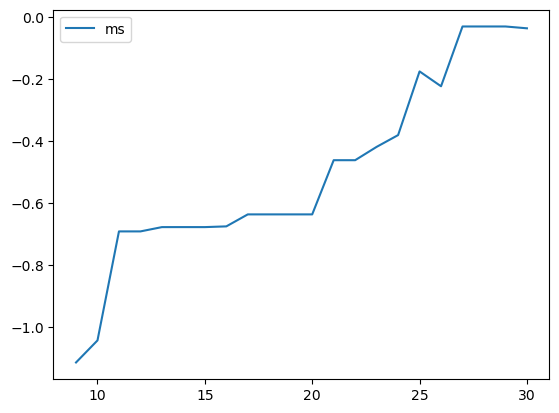

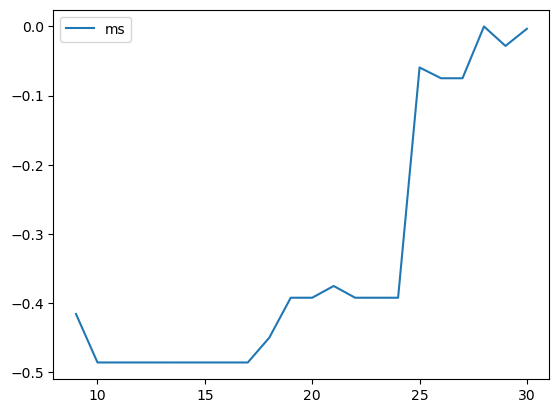

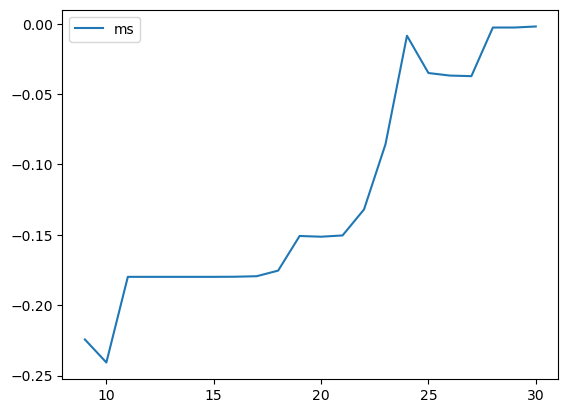

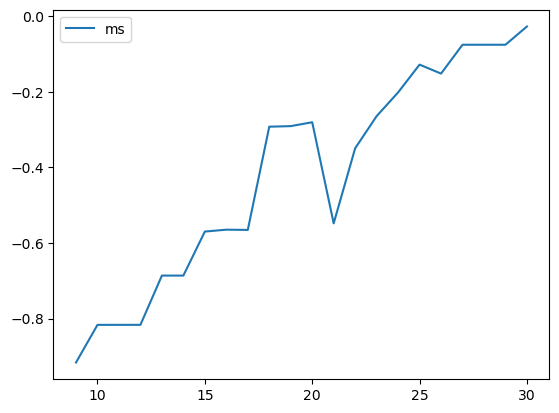

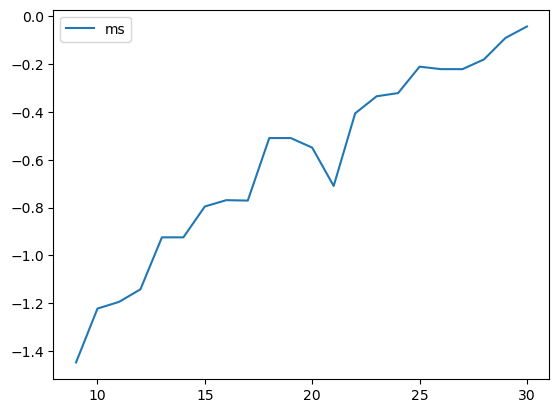

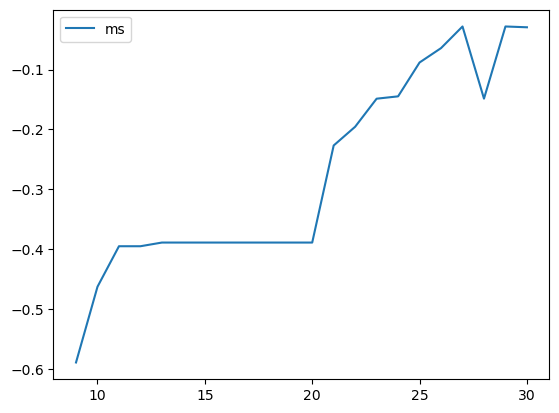

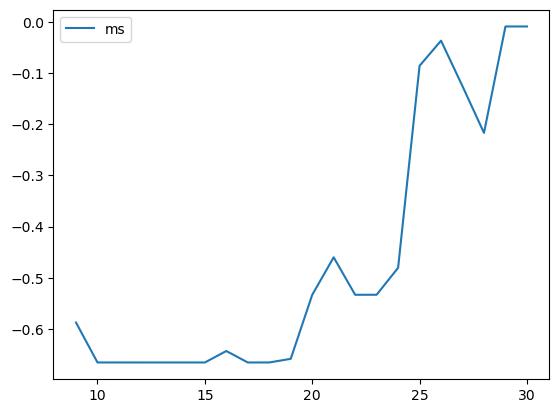

[-1.5990428373367098, -1.4057085142319048, -0.84657994402793, -0.1985576226637651, -0.9377226457118875, -1.1438893885620616, -0.3528986377383263, -1.1138009432573064, -0.3355894232115668, -0.13834052294735022, -1.5363066666512473, -0.3449713052927321, -2.4595467514893983, -1.115143557883767, -0.4161289716902987, -0.22437642226935461, -0.9162351236542665, -1.4477710211283883, -0.589360200228755, -0.5875373611926111]
[-1.4472762026664152, -1.30529205303216, -0.7876785541985454, -0.2732874577877584, -0.8862414206204088, -0.8466488738950826, -0.34005621447347767, -0.9683645790998239, -0.3671282127857274, -0.13750270514521862, -1.3441419877349292, -0.2337385257894674, -2.214894649480721, -1.0439083319217421, -0.4862031792449988, -0.24072504923712212, -0.8166619282721763, -1.2222536011562775, -0.4628586195427348, -0.6654936354143497]
[-1.421459113066504, -1.0629993182161308, -0.6137493547133422, -0.27311718129199347, -0.722144789823687, -0.6992416078972203, -0.3400702261401578, -0.7416664045

In [ ]:
plt.figure()
plt.plot(k_list, LB_history, label="LB")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_list, UB_history, label="UB")
plt.legend()
plt.show()

plt.figure()
plt.plot(k_list, sum_ms_list, label="LB sum")
plt.legend()
plt.show()

'''
for i in range(len(ms_history[0])):
    plt.figure()
    plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
    plt.legend()
    plt.show()
'''   
for item in ms_history:
    print(item)

In [ ]:
def evaluate_As_at(model, first_stg_vars, first_stg_vals, solver):
    for u, v in zip(first_stg_vars, first_stg_vals):
        u.fix(pyo.value(v))
    model.obj = pyo.Objective(expr=As, sense=pyo.minimize)
    results = solver.solve(model, tee=False)

    try:
        results = solver.solve(model, tee=False)
        status_ok = (results.solver.status == SolverStatus.ok)
        term_ok   = (results.solver.termination_condition == TerminationCondition.optimal)
        if not (status_ok and term_ok):
            raise RuntimeError(
                f"Scenario evaluate at y={first_stg_vals} not optimal: "
                f"status={results.solver.status}, term={results.solver.termination_condition}"
            )
        return pyo.value(model.obj_expr)
    finally:
        if hasattr(model, 'obj'):
            model.del_component('obj')
        for u in first_stg_vars:
            if u.fixed:
                u.unfix()
                

In [45]:
# ---- 生成“轴向等距插值点”（）----
def build_full_grid_points(first_stg_vars, n_per_axis=10, endpoint=True, round_ndigits=12):
    """
    生成全维等距笛卡尔网格：
    - first_stg_vars: [Kp, Ki, Kd, ...]，每个变量需要有 lb/ub
    - n_per_axis: int 或 序列（逐维个数），例如 10 或 [10,12,8]
    - endpoint: 是否包含右端点（np.linspace 的参数）
    - round_ndigits: 为了稳定，把坐标四舍五入到固定小数位，避免浮点毛刺造成“相同点判不同”
    返回：list[tuple]，长度为 ∏ n_per_axis
    """
    lbs = [float(v.lb) for v in first_stg_vars]
    ubs = [float(v.ub) for v in first_stg_vars]
    d = len(first_stg_vars)

    if isinstance(n_per_axis, int):
        counts = [n_per_axis] * d
    else:
        if len(n_per_axis) != d:
            raise ValueError("n_per_axis 的长度必须等于维度数")
        counts = list(n_per_axis)

    # 每一维的等距坐标
    grids = [
        np.linspace(lbs[i], ubs[i], counts[i], endpoint=endpoint)
        for i in range(d)
    ]

    # 笛卡尔积 -> 点
    pts = [
        tuple(round(float(x), round_ndigits) for x in coords)
        for coords in it.product(*grids)
    ]
    return pts
n_per_axis = 10
first_stg_grid_nodes = build_full_grid_points(first_stg_vars_list[0], n_per_axis=n_per_axis, endpoint=True, round_ndigits=12)
node_vals = []
for pts in first_stg_grid_nodes:
    node_vals.append(evaluate_As_at(model_list[0], first_stg_vars_list[0], pts, solver))
node_vals

[3.9007114612311216,
 2.3503441048745484,
 1.9104603615508695,
 1.6941793074016234,
 1.5664349008322929,
 1.4824497918564976,
 1.4231620187488767,
 1.3791317594072525,
 1.3451680478984742,
 1.3181867814258266,
 0.3660377086045538,
 0.32095931482637524,
 0.3234540835692534,
 0.3369910821069953,
 0.34605036737259154,
 0.3564343505233331,
 0.3739569496669427,
 0.3962007171844738,
 0.4186998584430933,
 0.4383053800091309,
 0.2147560667825593,
 0.2026925322040548,
 0.23030197311432712,
 0.2510243193151227,
 0.26735514499844354,
 0.28482261451244967,
 0.3013732308080738,
 0.314287711072649,
 0.32400564250854796,
 0.3325285934489534,
 0.16432073421043475,
 0.15990697945187313,
 0.18097721725912347,
 0.20215430340712462,
 0.22021189889336873,
 0.2350134315004603,
 0.24844109773493966,
 0.2622278320994963,
 0.27612077995468576,
 0.28893949406878666,
 0.14116745501822567,
 0.1411070763948227,
 0.15576105715314165,
 0.17305234431627986,
 0.18919173104921766,
 0.20383466602190697,
 0.2167435526661

In [46]:
def scatter_colored_points(first_stg_nodes, node_vals, mode="mpl", highlight_min=True):
    """
    mode: 'mpl' 或 'plotly'
    返回: (best_point, best_value)
    """
    pts = np.asarray(first_stg_nodes, dtype=float)
    vals = np.asarray(node_vals, dtype=float).ravel()
    if pts.size == 0 or vals.size == 0:
        raise ValueError("first_stg_nodes / node_vals 不能为空")
    if pts.shape[1] != 3:
        raise ValueError("first_stg_nodes 需为 N×3 的数组")

    # 最小值点
    idx = int(np.argmin(vals))
    best_point, best_value = pts[idx], float(vals[idx])

    if mode == "plotly":
 
        import pandas as pd
        import plotly.express as px
        import plotly.graph_objects as go
        df = pd.DataFrame({"Kp": pts[:,0], "Ki": pts[:,1], "Kd": pts[:,2], "Value": vals})
        fig = px.scatter_3d(df, x="Kp", y="Ki", z="Kd",
                            color="Value", color_continuous_scale="Viridis",
                            opacity=0.85)
        if highlight_min:
            fig.add_trace(go.Scatter3d(
                x=[best_point[0]], y=[best_point[1]], z=[best_point[2]],
                mode='markers',
                marker=dict(size=8, color='red', symbol='diamond'),
                name='Min Point'
            ))
        fig.update_layout(scene=dict(xaxis_title="Kp", yaxis_title="Ki", zaxis_title="Kd"),
                            title=f"Min value = {best_value:.6g} at {best_point}")
        fig.show()


    if mode == "mpl":
        import matplotlib.pyplot as plt
        fig = plt.figure(figsize=(7,6))
        ax = fig.add_subplot(111, projection='3d')
        sc = ax.scatter(pts[:,0], pts[:,1], pts[:,2],
                        c=vals, cmap='viridis', s=40, alpha=0.8)
        if highlight_min:
            ax.scatter(best_point[0], best_point[1], best_point[2],
                       c='red', s=120, marker='*', label='Min Point', depthshade=False)
            ax.legend(loc="best")
        ax.set_xlabel("Kp"); ax.set_ylabel("Ki"); ax.set_zlabel("Kd")
        cb = fig.colorbar(sc, ax=ax, label="Value")
        ax.set_title(f"Min value = {best_value:.6g} at {best_point}")
        plt.tight_layout(); plt.show()

    return best_point, best_value

bp, bv = scatter_colored_points(first_stg_grid_nodes, node_vals, mode="plotly")

In [14]:
# 先把某个点固定
model_list[0].Kp.fix(1.2)
model_list[0].Ki.fix(0.5)
model_list[0].Kd.fix(0.0)

# 然后直接计算 As
val = pyo.value(As)
print("piecewise value at this point:", val)


piecewise value at this point: 3.4843568749792015


In [12]:
def eval_pw(expr, vars_list, pts):
    vals = []
    for pt in pts:
        context = {v: val for v, val in zip(vars_list, pt)}
        vals.append(pyo.value(expr, context=context))
    return vals

# 使用示例
pts = [(0.5, 0.5, 0.5), (1.0, 0.0, 2.0)]
vals = eval_pw(As, first_stg_vars_list[0], pts)
print(vals)

TypeError: unhashable type: 'ScalarVar'

In [9]:
for i in range(N):
    del_components(model_list[i])
    As, _ = add_nd_piecewise(
        model_list[i],
        first_stg_vars_list[i],
        first_stg_nodes,
        as_nodes_list[i],
        name=f"pw_scen_{i}",
        relation="=="
    )

    # 2) 目标函数：min obj_expr - As_i
    model_list[i].obj = Objective(expr=model_list[i].obj_expr - As, sense=minimize)

def eval_pw(expr, vars_list, pts):
    vals = []
    for pt in pts:
        context = {v: val for v, val in zip(vars_list, pt)}
        vals.append(pyo.value(expr, context=context))
    return vals

# 使用示例
pts = [(0.5, 0.5, 0.5), (1.0, 0.0, 2.0)]
vals = eval_pw(As, first_stg_vars_list[0], pts)
print(vals)


TypeError: unhashable type: 'ScalarVar'

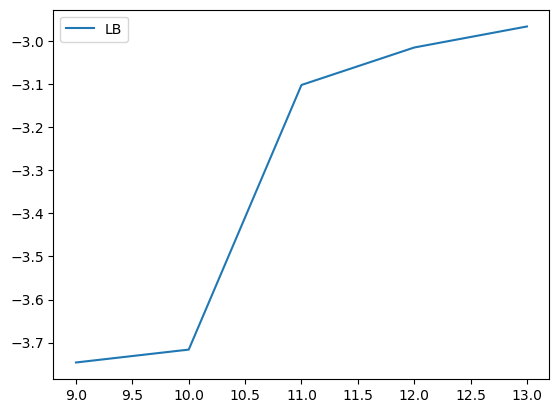

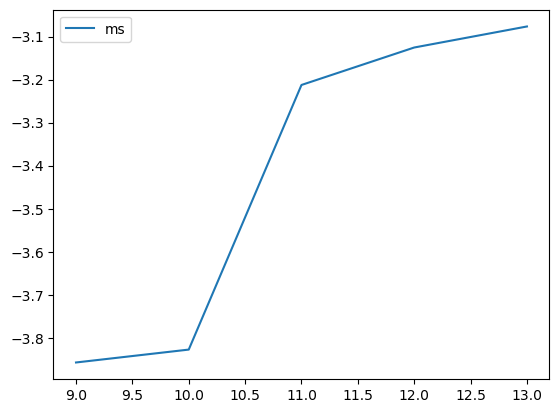

[-3.857168545186457]
[-3.827229109876515]
[-3.212551333575405]
[-3.1255403718660686]
[-3.0766723934664038]


In [2]:
plt.figure()
plt.plot(k_list, LB_list, label="LB")
plt.legend()
plt.show()

for i in range(len(ms_history[0])):
    plt.figure()
    plt.plot(k_list, [ms[i] for ms in ms_history], label="ms")
    plt.legend()
    plt.show()
    
for item in ms_history:
    print(item)

In [17]:
for item in fsv_nodes_list:
    print(len(item))
    print(item)

8
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0)]
9
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477)]
10
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477), (0.0, 0.650605510566782, 0.6506055105667817)]
11
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477), (0.0, 0.650605510566782, 0.6506055105667817), (0.9685055475308644, 0.49219590647283035, 4.155587041664758e-10)]
12
[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0

In [13]:
UB_node_history

[(10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0),
 (10.0, 10.0, 0.0)]

8
0


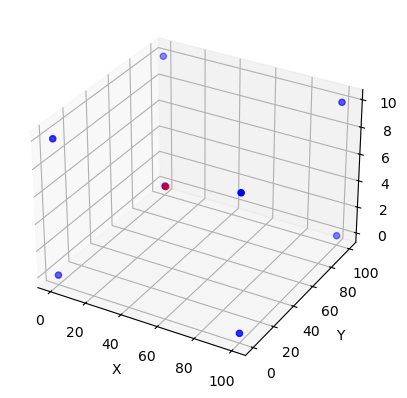

9
1


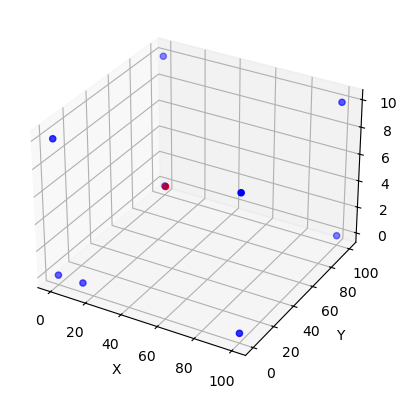

10
2


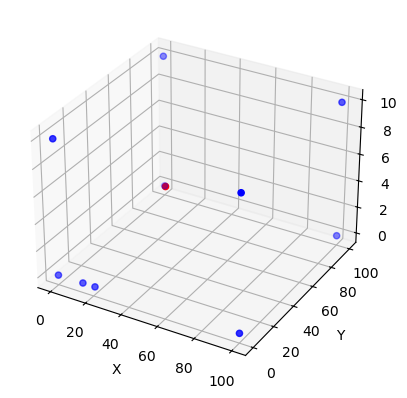

11
3


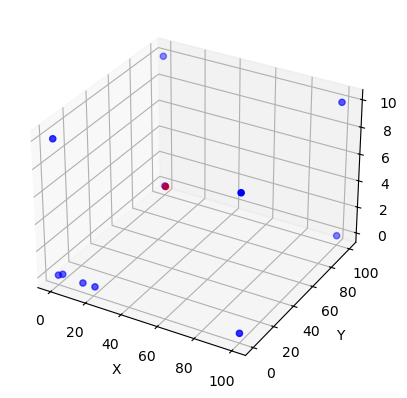

12
4


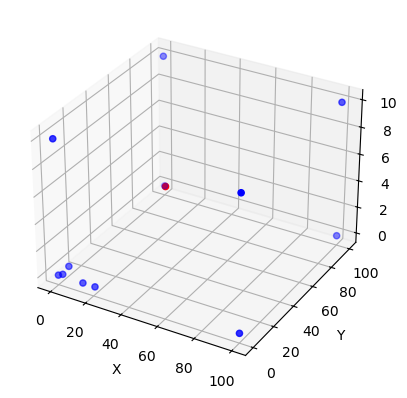

13
5


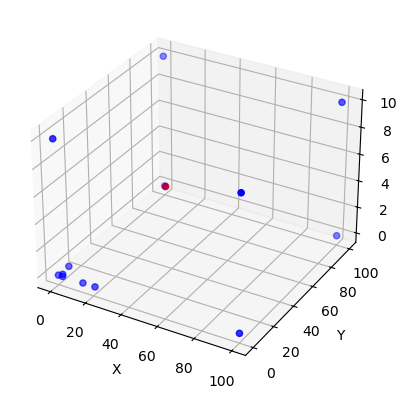

In [18]:
for i in range(len(fsv_nodes_list)):
    points = fsv_nodes_list[i]
    UB_pt = UB_node_history[i]
    print(len(points))
    print(i)
    xs = [p[0] for p in points]
    ys = [p[1] for p in points]
    zs = [p[2] for p in points]
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(xs, ys, zs, c='b', marker='o')
    ax.scatter(UB_pt[0], UB_pt[1], UB_pt[2], c='r', marker='o')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    plt.show()

In [29]:
# calculate one time
model_list, first_stg_vars_list, m_tmpl_list, T = build_models_from_csv(
    csv_path, h=0.2, weights=weights, bounds=bounds,
    sp0=0.0, sp1=0.5, ku_col="tau_us", tau_col="tau_xs",
    disturb_prefix="disturbance_", setpoint_change_col="setpoint_change",
    max_scenarios=max_scenarios, skip=0
)
solver2 = SolverFactory('gurobi')
solver2.options.update({
    'MIPGap': 1e-3,
    'FeasibilityTol': 1e-6,
    'IntFeasTol':     1e-6,
    'OptimalityTol':  1e-6,
    'NumericFocus':   0,
    'Presolve':       2,
    'NonConvex':      2,
    'TimeLimit':      120,
    'MIPFocus':       1,
})

# warm start 存储
global warm_solutions
warm_solutions = [None for _ in model_list]


first_stg_nodes = fsv_nodes_list[11]
as_nodes_list = [[] for _ in range(N)]
for i in range(N):
    for node in first_stg_nodes:
        as_nodes_list[i].append(evaluate_Q_at(model_list[i], first_stg_vars_list[i], node, solver2))

print(first_stg_nodes)
print('pts number is ',len(first_stg_nodes))

timeuse = []

for i in range(len(model_list)):
    print('##################################################')
    print('##################################################')
    print('##################################################')
    print('\nSolving scenario ', i)
    del_components(model_list[i])
    As, _ = add_nd_piecewise(
        model_list[i],
        first_stg_vars_list[i],
        first_stg_nodes,
        as_nodes_list[i],
        name=f"pw_scen_{i}",
        relation="=="
    )

    model_list[i].obj = Objective(expr=model_list[i].obj_expr - As, sense=minimize)

    # 先线性化，再绑定 persistent
    apply_pw_transform(model_list[i])
    assert_no_plf_left(model_list[i], where=f"scenario-{i}")
    apply_warm_values(model_list[i], warm_solutions[i])


    start = time.time()
    #results = opt.solve(tee=True)
    results = solver2.solve(model_list[i], tee=True)
    end = time.time()


    print('**************************************************')
    print('**************************************************')
    print(f"scenario {i}, 计算Q与As最大差值（ms）用时: {end - start:.4f} 秒")
    print('**************************************************')
    print('**************************************************')
    timeuse.append(end - start)

[(0.0, 0.0, 0.0), (0.0, 0.0, 10.0), (0.0, 10.0, 0.0), (0.0, 10.0, 10.0), (10.0, 0.0, 0.0), (10.0, 0.0, 10.0), (10.0, 10.0, 0.0), (10.0, 10.0, 10.0), (3.912444184890257e-07, 0.9045883573264254, 0.9045883332436477), (0.0, 0.650605510566782, 0.6506055105667817), (0.9685055475308644, 0.49219590647283035, 4.155587041664758e-10), (0.8476346428632943, 0.5062385639700913, 0.0), (1.6558394650127024, 0.0, 0.0), (0.0, 0.7180137951567623, 0.0), (0.3398847059878209, 0.0, 0.8357961904350453), (0.0, 0.0, 2.25606001958985), (1.1905698548827046, 1.1917093697185561, 1.9874603145770062), (0.29453818957864014, 0.14968472981920103, 0.0), (0.5367318701314108, 0.0, 0.0)]
pts number is  19
##################################################
##################################################
##################################################

Solving scenario  0
Read LP format model from file C:\Users\pc\AppData\Local\Temp\tmpl21sks6d.pyomo.lp
Reading time = 0.01 seconds
x1: 81 rows, 267 columns, 1895 nonzeros


In [13]:
import pandas as pd, json

rows = []
n = len(k_list)

def safe_get(L, i, default=None):
    return L[i] if i < len(L) else default

for i in range(n):
    rows.append({
        "k": k_list[i],
        "LB": safe_get(LB_history, i),
        "UB": safe_get(UB_history, i),
        "gap": (safe_get(UB_history, i) - safe_get(LB_history, i)
                if i < len(LB_history) and i < len(UB_history) else None),
        "sum_ms": safe_get(sum_ms_list, i),
        "ms": json.dumps(safe_get(ms_history, i)),
        "added_nodes": json.dumps(safe_get(add_node_history, i)),
        "UB_node": json.dumps(safe_get(UB_node_history, i)),
        "new_nodes": json.dumps(safe_get(new_nodes_list, i)),
        "as_nodes": json.dumps(safe_get(as_nodes_list, i)),
    })

df = pd.DataFrame(rows)
df.to_csv("mydata3.csv", index=False)
print("数据已保存")

数据已保存
